# Importing required libraries

In [1]:
import numpy as np
import tensorflow as tf #for deep learning tasks
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers # To create a neural network

# Storing data into tensorflow dataset

In [2]:
BATCH_SIZE = 16
LG_IMGSIZE = (256,256)
SM_IMGSIZE = (32,32)

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "C:/Users/OKHAI SADO/Downloads/ML home classes/Maize leaf disease/MaizeLeafDisease",
    batch_size = BATCH_SIZE,
    image_size = LG_IMGSIZE,
    shuffle = True,
    seed = 123 # To produce the same result eveytime they run the code.
)

Found 4188 files belonging to 4 classes.


###### Here’s a quick summary:

Total Images: 4188<br>
Batch Size: 16<br>

Breakdown of the images per class:<br>
Blight - 1146 Images<br>
Common Rust - 1306 Images<br>
Gray Leaf Spot - 574 Images<br>
Healthy - 1162 Images<br>

In [4]:
class_names = dataset.class_names
class_names

['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']

In [5]:
len(dataset)

262

##### This means your dataset is split into 262 batches of 16 images each (with the last batch possibly having fewer images).

In [6]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(16, 256, 256, 3)
[0 3 0 2 1 0 2 3 1 3 0 3 0 0 3 3]


###### Analysis
(16, 256, 256, 3): This indicates that each batch contains 16 images, each of size 256x256 pixels with 3 color channels (RGB).<br>
[1 3 0 2 2 0 0 1 1 3 0 3 0 0 1 2 1 1 0 2 3 1 3 3 2 3 2 0 0 1 0 3]: 
This array represents the labels for the 16 images in the batch. Each number corresponds to a class label for an image.

# Visualization of an image from the tf dataset

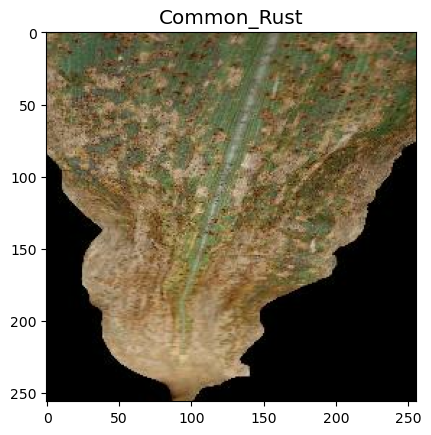

In [7]:
for image_batch, label_batch in dataset.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.title(class_names[label_batch[0]], fontsize='x-large', fontweight='ultralight')
    plt.show()

In [8]:
EPOCHS = 50 #To run each images

# Split Training, Validation, Testing Sets

**80%** training set<br>
**10%** validation set<br>
**10%** test set<br>

In [9]:
def get_partitioned_datasets(dataset, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
        if shuffle:
            dataset = dataset.shuffle(shuffle_size, seed=123)

        dataset_len = len(dataset)
    
        train_len = int(train_split*dataset_len)
        train_dataset = dataset.take(train_len)
        dataset = dataset.skip(train_len)

        val_len = int(val_split*dataset_len)
        val_dataset = dataset.take(val_len)
        dataset = dataset.skip(val_len)

        test_len = dataset_len - train_len - val_len
        test_dataset = dataset.take(test_len)

        return train_dataset, val_dataset, test_dataset

In [10]:
train_dataset, val_dataset, test_dataset = get_partitioned_datasets(dataset)

In [11]:
print(f'Training set size: {len(train_dataset)} batches')
print(f'Validation set size: {len(val_dataset)} batches')
print(f'Test set size: {len(test_dataset)} batches')

Training set size: 209 batches
Validation set size: 26 batches
Test set size: 27 batches


The get_partitioned_datasets function is used to split the dataset into training, validation, and testing sets.<br>
This approach provides more flexibility and control over the dataset splits compared to the built-in validation_split parameter.<br>
Specifically, it allows us to explicitly define the proportions for training (80%), validation (10%), and testing (10%) sets.<br>
This ensures that we have a separate test set, which is crucial for evaluating the final performance of the model on unseen data.<br>
Additionally, the function includes an option to shuffle the dataset, ensuring that the data is randomly distributed across the splits.


In [12]:
# To make the data work faster and more efficiently.
train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_dataset.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

**[Shuffle(1000)]**<br>
**Purpose:** Shuffling the dataset ensures that the data is randomly distributed, which helps prevent the model from learning any unitended patterns or bias from the oder of the data.<br>
**Parameter (1000):** The buffer size (1000) determines how many elements are shuffled at a time.<br>

**[prefectch(buffer_size=tf.data.AUTOTUNE)]**<br>
**Purpose:** Prefetching allows the data loading to overlap with the model training. While the model is training on the current batch, the next batch is being prepared in the background. This helps keep the GPU/CPU busy and reduces Idle time.<br>
**Parameter(tf.data.AUTOTUNE):** Using AUTOTUNE lets TensorFlow automatically determine the optimal buffer size for prefetching, balancing between memory usage and performance.

# Data Augumentation

In [13]:
# To resize and rescale all images to the same size and scale 
ONE_IMAGE_SIZE = 256 # To Define the target an image size

resize_and_rescale = tf.keras.Sequential([
    #Resize images to 256x256 pixels
    layers.Resizing(ONE_IMAGE_SIZE, ONE_IMAGE_SIZE),
    #Rescale pixel values from [0,255] to [0,1]
    layers.Rescaling(1.0/255)
])

## Brief 
**Resizing:**<br>
**Purpose:** The layers.Resizing(ONE_IMAGE_SIZE, ONE_IMAGE_SIZE) layer resizes all images to a uniform size of 256x256 pixels. This ensures that all images have the same dimensions, which is necessary for batching and feeding them into the neural network.<br>
**Benefit:** Consistent image sizes make it easier to process the data and train the model.<br>

**Rescaling:**
**Purpose:** The layers.Rescaling(1.0/255) layer rescales the pixel values of the images from the range [0, 255] to [0, 1]. Each pixel value is divided by 255.<br>
**Explanation:** Every pixel in an image has an intensity value between 0 and 255. By dividing each pixel value by 255, we normalize the pixel values to a range between 0 and 1. This normalization helps the model learn more effectively and reduces the risk of numerical instability during training.<br>
**Benefit:** Rescaling the pixel values to a smaller range helps the neural network train more efficiently. Smaller input values lead to faster convergence and more stable training. This is because neural networks generally perform better when the input values are normalized to a smaller range.<br>

In [14]:
data_augmentation = tf.keras.Sequential([
    # Randomly flip images horizontally and vertically.
    layers.RandomFlip("horizontal_and_vertical"),
    # Randomly rotate images by up to 20%.
    layers.RandomRotation(0.2),
    # Randomly zool into images by up to 20%.
    layers.RandomZoom(0.2),
    # Randomly translate images by up to 20% of their height and width.
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    # Randomly adjust the contrast of images by up to 20%
    layers.RandomContrast(0.2),
    # Randomly adjust the brightness of images by up to 20%
    layers.RandomBrightness(0.2)
])

### Detailed Explanation
**RandomFlip:**<br>
Purpose: Randomly flips images horizontally and vertically.<br>
Benefit: Helps the model learn to recognize objects regardless of their orientation.<br>
**RandomRotation:**<br>
Purpose: Randomly rotates images by up to 20% of a full circle.<br>
Benefit: Introduces rotational variations, making the model more robust to different angles.<br>
**RandomZoom:**<br>
Purpose: Randomly zooms into images by up to 20%.<br>
Benefit: Helps the model handle variations in object size and scale.<br>
**RandomTranslation:**<br>
Purpose: Randomly translates (shifts) images by up to 20% of their height and width.<br>
Benefit: Makes the model more robust to positional variations.<br>
**RandomContrast:**<br>
Purpose: Randomly adjusts the contrast of images by up to 20%.<br>
Benefit: Helps the model handle variations in lighting and contrast.<br>
**RandomBrightness:**<br>
Purpose: Randomly adjusts the brightness of images by up to 20%.<br>
Benefit: Introduces variations in brightness, making the model more robust to different lighting conditions.<br>

# Why Use Data Augmentation?
Even though you already have training, validation, and test datasets, data augmentation is beneficial because it artificially increases the diversity and size of your training data. Here’s why it’s useful:

**Improves Model Robustness:** By creating variations of your existing images (e.g., through zooming, rotating, flipping), you expose your model to a wider range of scenarios. This helps the model generalize better to new, unseen data.<br>
**Reduces Overfitting:** Data augmentation helps prevent overfitting by ensuring the model doesn’t memorize the training data. Instead, it learns to recognize patterns and features that are invariant to transformations.<br>
**Increases Training Data:** Augmenting your data effectively increases the size of your training dataset without the need for collecting more data. This is especially useful when you have a limited amount of original data.<br>

You can simply create more data and make your model more robust and more accurate. For example, you can create new data by only zooming or rotating your training data, and you will have more images. That’s an easy way to make your neural network better.

In [15]:
# Number of color channels (e.g. RGB).
CHANNELS = 3
# Shape of the input data.
input_shape = (BATCH_SIZE, ONE_IMAGE_SIZE, ONE_IMAGE_SIZE, CHANNELS) 
# Number of output classes
n_classes = 4 

model = models.Sequential([
    # Preprocessing layer to resize and rescale images.
    resize_and_rescale, 
    
    # FIRST PART OF THE CONVOLUTIONAL NEURAL NETWORK (CNN).
    # First convolutional layer
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    # First max pooling layer
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional layer
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    # Second max pooling
    layers.MaxPooling2D((2, 2)),
    
    # Third convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Third max pooling 
    layers.MaxPooling2D((2, 2)),
    
    # Fourth convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Fourth max pooling
    layers.MaxPooling2D((2, 2)),
    
    # SECOND PART OF THE CONVOLUTIONAL NEURAL NETWORK (CNN)
    # Flattening the 3D output to 1D
    layers.Flatten(),
    # Fully connected layer with ReLU activation
    layers.Dense(64, activation='relu'),
    # Output layer with softmax activation
    layers.Dense(n_classes, activation='softmax'),
])

# Building the model with the specified input shape.
model.build(input_shape=input_shape)

C:\Users\OKHAI SADO\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Explanation
The first part of the convolution neural network is responsible for recognizing the feautures and connecting these features to bigger patterens. This part includes the convolutional and pooling layers and  then these features will be input for the second part of the neural network.

The second part of the CNN is responsible for classification.it takes the feautures extracted from the convolutional layers which classify the input i.e wether the image is it or not.

WHAT IS RELU ACTIVATION FUNCTION?<br>
It makes all negative numbers 0 and all positive number stay

WHY WE USE RELU ACTIVATION FUNCTION?<br>
ReLU helps with making the model nonlinear. We have two types of functions in neural networks the base function(linear function) and activation function. The base function combines input multiplied by weights plus biases into a neuron and the activation function add non-linearity to the neuron to solve more complex problems.

WHY WE USE SOFTMAX ACTIVATION FUNCTION?<br>
In the last layer, there are  4 neurons corresponding to the 4 output classes. The sofmax activation function converts the raw output scores into probabilities, ensuring that the sum of all probabilities is 1. The class with the highest probability will be selected as the final result.<br>

WHAT IS MAXPOOLING?<BR>
MaxPooling is a down-sampling technique used to reduce the spatial dimensions of the input volume.<br>

WHAT IS A PURPOSE OF POOLING?<br>
To reduce a size of inputs. For example layers.MaxPooling2D((2, 2)) takes a window 2x2 and  pick the maximum value and ureduced the block to only one pixel. Filtering the noice, random numbers somewhere, making the model more robust and efficient.

In [16]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (16, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (16, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (16, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (16, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (16, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (16, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (16, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (16, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (16, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (16, 12544)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (16, 64)                    │         802,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (16, 4)                     │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 896,388 (3.42 MB)

 Trainable params: 896,388 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Summary Breakdown
Model: “sequential_3”: This is the name of your model.<br>
Layer (type): The name and type of each layer in your model.<br>
Output Shape: The shape of the output tensor from each layer.<br>
Param #: The number of parameters (weights and biases) in each layer.<br>

## To measure the accuracy of our neural network 

In [17]:
# loss function measures how well the model's predictions match the true labels
# Optimizer updates the model's weights to minimize the loss function
# Metrics evaluate the whole model, its performance using varius criteria, for example accuracy

model.compile(
   optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'] 
)

### Explanation:
**Optimizer:** The optimizer will make changes to the weights, and these changes will help reduce the value of the loss function, making the model more accurate.<br>
**Loss Function:** The loss function helps to determine the difference between our predicted labels and the true labels. By minimizing ths differences, the model's predictions become more accurate.<br>
**Metrics:** Metrics like accuracy help in evaluating the overall performance of the model using various criteria.

In [18]:
# Fit means training in the topics of neural networks
history = model.fit(
    train_dataset,
    batch_size=BATCH_SIZE,
    validation_data=val_dataset,
    verbose=1,
    epochs=8,
)

Epoch 1/8
209/209 ━━━━━━━━━━━━━━━━━━━━ 146s 661ms/step - accuracy: 0.6684 - loss: 0.7837 - val_accuracy: 0.7981 - val_loss: 0.5947
Epoch 2/8
209/209 ━━━━━━━━━━━━━━━━━━━━ 139s 644ms/step - accuracy: 0.8415 - loss: 0.4097 - val_accuracy: 0.8486 - val_loss: 0.3661
Epoch 3/8
209/209 ━━━━━━━━━━━━━━━━━━━━ 141s 652ms/step - accuracy: 0.8649 - loss: 0.3479 - val_accuracy: 0.8894 - val_loss: 0.3095
Epoch 4/8
209/209 ━━━━━━━━━━━━━━━━━━━━ 145s 673ms/step - accuracy: 0.8779 - loss: 0.2965 - val_accuracy: 0.8942 - val_loss: 0.2472
Epoch 5/8
209/209 ━━━━━━━━━━━━━━━━━━━━ 148s 685ms/step - accuracy: 0.8966 - loss: 0.2634 - val_accuracy: 0.9207 - val_loss: 0.1853
Epoch 6/8
209/209 ━━━━━━━━━━━━━━━━━━━━ 134s 622ms/step - accuracy: 0.8962 - loss: 0.2518 - val_accuracy: 0.9150 - val_loss: 0.1991
Epoch 7/8
209/209 ━━━━━━━━━━━━━━━━━━━━ 135s 624ms/step - accuracy: 0.9243 - loss: 0.2025 - val_accuracy: 0.9471 - val_loss: 0.1418
Epoch 8/8
209/209 ━━━━━━━━━━━━━━━━━━━━ 135s 624ms/step - accuracy: 0.9294 - loss: 0

### Interpretation:
**Accuracy and Loss:** The model's accuracy improved significantly from 66.14% to 92.94% over the 8 epochs, while the loss decreased from 0.7837 to 0.1774. This indicates that the model is learning and improving its predictions.<br>

**Validation Metrics:** The validation accuracy and loss also show improvement, indicating that the model is generalizing well to unseen data. The final validation accuracy is (91.26% and validation loss is 0.1955.<br>

**Overall, the model seems to be performing well.**

In [19]:
# To test performance of the model on new dataset.
model.evaluate(test_dataset)

27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.9443 - loss: 0.1314


[0.16883575916290283, 0.9305555820465088]

In [20]:
history

# TO PREDICTON

The first image to predict
The first image's actual label: Common_Rust


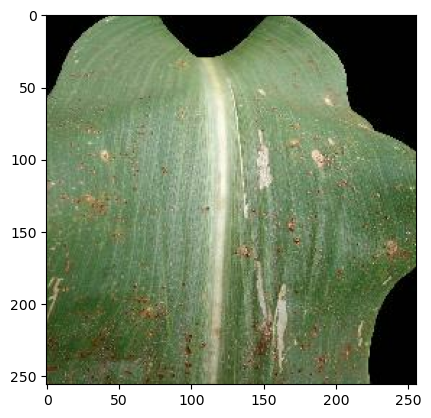

In [21]:
# visualize an image with the predicted label
for images_batch, labels_batch in test_dataset.take(1): # For 1 batch
    
    # For the first batch
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0]
    
    print("The first image to predict")
    plt.imshow(first_image)
    print("The first image's actual label:", class_names[first_label])


In [22]:
# To confirm Its the actual model.
batch_prediction = model.predict(images_batch)
print("Predicted label:", class_names[np.argmax(batch_prediction[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step
Predicted label: Common_Rust


In [23]:
def predict(model, img,top_n=3, threshold=70):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)
    
    #Get the top N predicted classes and confidense levels
    top_n_indices = np.argsort(predictions[0])[-top_n:][::-1] #Top N predictions
    top_n_confidences = [round(100 * predictions[0][idx],2)for idx in top_n_indices]
    
    #Check if any of the top N predictions exceed the threshold
    for idx, confidence in zip(top_n_indices, top_n_confidences):
        if confidence >= threshold:
            return f"Known: {class_names[idx]}", confidence
    #If none of the top predictions meet the threshold, mark as "Unkwown"
    return "Unknown", max(top_n_confidense)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


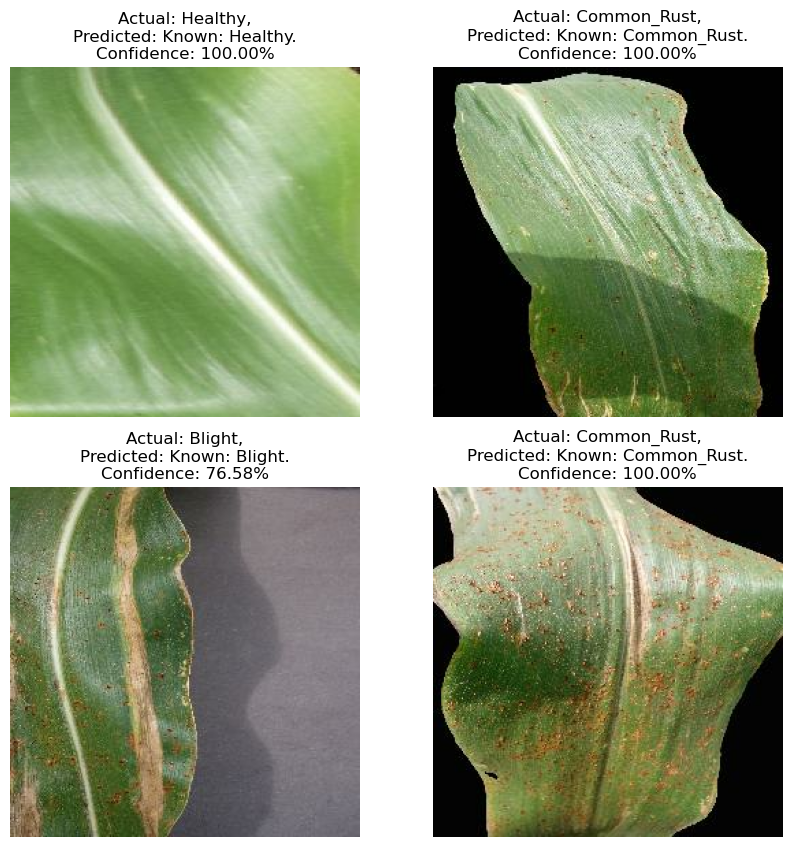

In [24]:
plt.figure(figsize=(10, 10))  

# Iterate over one batch of images and labels from the test dataset
for images, labels in test_dataset.take(1):
    for i in range(4):  # The range to 4 to show only 4 images
        ax = plt.subplot(2, 2, i + 1)  # the grid to 2x2
        plt.imshow(images[i].numpy().astype("uint8"))

        #Predict and display
        predicted_class, confidence = predict(model, images[i].numpy())
        
        #Converted the labor tensor to a numpy array and get its integer value
        actual_class_idx = labels[i].numpy()
        actual_class = class_names[actual_class_idx]
        
        plt.title(f"Actual: {actual_class},\nPredicted: {predicted_class}.\nConfidence: {confidence:.2f}%")
        plt.axis("off")
plt.show()

#### 
***Top-N predictions;***
This method looks at the top-N most confident predictions (e.g. top-3). If any of these predictions have a confidense level higher than the threshold, its considered a "Known maize Plant Disease."

***Improvement;***
This allows the model to be more flexible when it is unsure about the exact class but still recognizes the image as a maize leaf disease.
